# Inspect images

In [8]:
import matplotlib.pyplot as plt
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
%matplotlib inline

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
data_directory='./Data/train'

In [11]:
pic1 = cv2.imread('./Data/train/chickens/01I4JR8PX3B8.jpg')
pic1 = cv2.cvtColor(pic1, cv2.COLOR_BGR2RGB)

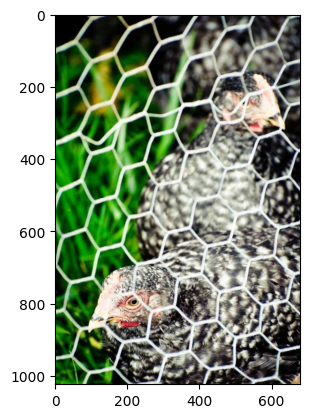

In [12]:
plt.imshow(pic1)

In [8]:
pic1.shape

(1024, 678, 3)

In [11]:
image_gen = ImageDataGenerator(rotation_range=30,
                              width_shift_range=0.1,
                              height_shift_range=0.1,
                              rescale=1/255,
                              shear_range=0.2,
                              zoom_range=0.2,
                              horizontal_flip=True,
                              fill_mode='nearest')

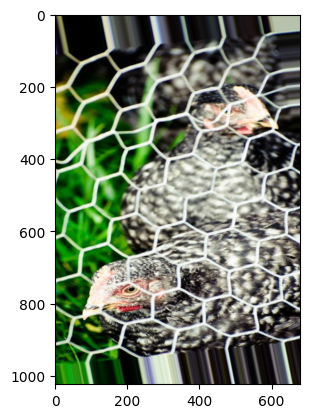

In [12]:
plt.imshow(image_gen.random_transform(pic1))

In [13]:
image_gen.flow_from_directory(data_directory)

Found 1319 images belonging to 4 classes.


In [14]:
from keras.models import Sequential

In [17]:
from keras.layers import Activation, Dropout, Flatten, Conv2D, MaxPooling2D, Dense

In [ ]:
input_shape=(224,224,3)

In [18]:
# Số lớp cần phân loại (4 lớp: chó, mèo, lợn, gà)
num_classes = 4

model = Sequential()

# Block 1
model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=(224,224,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))  # Bỏ input_shape ở các layer sau
model.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Lớp đầu ra: Số units = num_classes, activation='softmax'
model.add(Dense(num_classes, activation='softmax'))  # Thay sigmoid bằng softmax

# Compile với loss='categorical_crossentropy' (hoặc 'sparse_categorical_crossentropy' nếu nhãn là số nguyên)
model.compile(
    loss='categorical_crossentropy',  # Dùng cho one-hot encoded labels
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 43264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       5,537,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,594,756 (21.34 MB)

 Trainable params: 5,594,756 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
train_generator = image_gen.flow_from_directory(
    'data/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'  # Hoặc 'sparse' nếu dùng sparse_categorical_crossentropy
)

Found 1319 images belonging to 4 classes.


In [21]:
train_generator.class_indices

{'cats': 0, 'chickens': 1, 'dogs': 2, 'pigs': 3}

In [ ]:
results = model.fit(train_image_gen, epochs=1, steps_per_epoch =1319//32,
                             validation_data=test_image_gen,validation_steps=12)

In [22]:
import tensorflow as tf
print("GPU có sẵn:", tf.config.list_physical_devices('GPU'))
print("Phiên bản TensorFlow:", tf.__version__)

GPU có sẵn: []
Phiên bản TensorFlow: 2.19.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2L

print("TensorFlow version:", tf.__version__)
model = EfficientNetV2L(weights='imagenet')
model.summary()

TensorFlow version: 2.19.0
215760896/478307632 ━━━━━━━━━━━━━━━━━━━━ 57s 0us/step

In [1]:
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np

In [3]:
import matplotlib.pyplot as plt

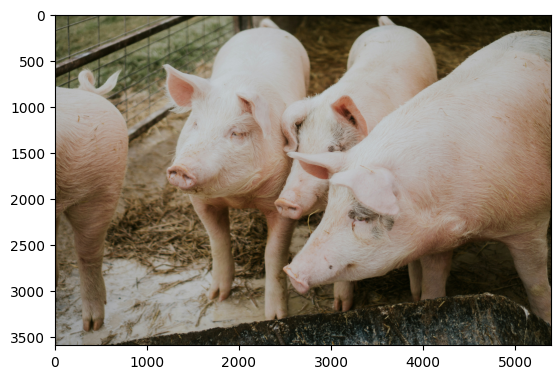

In [18]:
img = cv2.imread('./Data/test/pigs/amber-kipp-EwJMBIshgXU-unsplash.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [16]:
img = image.load_img('./Data/test/pigs/amber-kipp-EwJMBIshgXU-unsplash.jpg', target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Thêm chiều batch (1, 224, 224, 3)

# Tiền xử lý
processed_img = preprocess_input(img_array)

In [17]:
processed_img

array([[[[ 67.,  72.,  40.],
         [ 69.,  74.,  42.],
         [ 70.,  75.,  43.],
         ...,
         [ 21.,  19.,   4.],
         [ 20.,  21.,   5.],
         [ 22.,  23.,   9.]],

        [[ 83.,  87.,  54.],
         [ 74.,  80.,  46.],
         [ 56.,  63.,  29.],
         ...,
         [ 20.,  19.,   1.],
         [ 18.,  19.,   5.],
         [ 20.,  21.,   5.]],

        [[ 79.,  82.,  51.],
         [ 60.,  66.,  32.],
         [ 67.,  73.,  39.],
         ...,
         [ 22.,  20.,   7.],
         [ 23.,  21.,   8.],
         [ 18.,  16.,   1.]],

        ...,

        [[110., 103.,  85.],
         [121., 122., 116.],
         [149., 149., 147.],
         ...,
         [ 28.,  24.,  15.],
         [ 20.,  22.,  11.],
         [ 30.,  33.,  16.]],

        [[ 86.,  84.,  71.],
         [143., 145., 142.],
         [149., 150., 152.],
         ...,
         [ 23.,  25.,  14.],
         [ 21.,  23.,  12.],
         [ 29.,  27.,  12.]],

        [[117., 114., 105.],
       

In [23]:
import tensorflow as tf

In [24]:
model = tf.keras.models.load_model("./model/27042025besst_modelhihi.keras")

In [25]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generator cho dữ liệu test
test_generator = test_datagen.flow_from_directory(
    './Data/test/',
    target_size=(480, 480),  # Khớp với kích thước training
    batch_size=32,
    class_mode='categorical',
    shuffle=False,  # Giữ nguyên thứ tự để đánh giá chính xác
    seed=42  # Thêm seed để reproduce kết quả
)

Found 200 images belonging to 4 classes.


In [26]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

D:\ai-env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 572s 75s/step - accuracy: 0.9862 - loss: 0.0308 - precision_2: 0.9862 - recall_2: 0.9862
Test Loss: 0.0221
Test Accuracy: 0.9900
Test Precision: 0.9900
Test Recall: 0.9900


In [28]:
print(test_generator.class_indices)

{'cats': 0, 'chickens': 1, 'dogs': 2, 'pigs': 3}


In [30]:
from tensorflow.keras.preprocessing import image

In [31]:

img_path = './Data/test/pigs/Lon_18.jpg'


img = image.load_img(img_path, target_size=(480, 480))


img_array = image.img_to_array(img)


img_array = np.expand_dims(img_array, axis=0)

img_array = tf.keras.applications.efficientnet_v2.preprocess_input(img_array)


In [33]:
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions)

class_indices = {'cats': 0, 'chickens': 1, 'dogs': 2, 'pigs': 3}
class_names = list(class_indices.keys())

print("Predicted probabilities:", predictions)
print("Predicted class:", class_names[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted probabilities: [[5.1314392e-10 2.4523910e-09 1.7433685e-10 1.0000000e+00]]
Predicted class: pigs


In [34]:
predictions

array([[5.1314392e-10, 2.4523910e-09, 1.7433685e-10, 1.0000000e+00]],
      dtype=float32)

In [36]:
# Định nghĩa class names và indices
class_indices = {'cats': 0, 'chickens': 1, 'dogs': 2, 'pigs': 3}
class_names = list(class_indices.keys())

# Tính phần trăm xác suất (softmax nếu model chưa áp dụng)
probabilities = predictions[0]  # Lấy phần tử đầu tiên (batch size=1)

# In kết quả chi tiết
print("\nPredicted probabilities (percentages):")
for i, (class_name, prob) in enumerate(zip(class_names, probabilities)):
    print(f"{class_name}: {prob * 100:.2f}%")

print("\nPredicted class:", class_names[predicted_class_index])
print("Confidence:", f"{probabilities[predicted_class_index] * 100:.2f}%")


Predicted probabilities (percentages):
cats: 0.00%
chickens: 0.00%
dogs: 0.00%
pigs: 100.00%

Predicted class: pigs
Confidence: 100.00%
